In [53]:
import json
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
from collections import defaultdict
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from modules_segmentation import *


In [83]:
# function to compute if a box is covered by the mask (with a threshold)

def compute_mask_coverage(mask, rectangles, threshold=0.8):
    """
    mask: np.ndarray (grayscale, same size as original image)
    rectangles: list of rectangles [(x_min, y_min, x_max, y_max), ...]
    Returns: list of (rect_idx, coverage_ratio, is_covered)
    """
    results = []
    for i, (x1, y1, x2, y2) in enumerate(rectangles):
        #x2 = x1 + w
        #y2 = y1 + h
        # Ensure bounds within image
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(mask.shape[1], int(x2)), min(mask.shape[0], int(y2))
        if x2 <= x1 or y2 <= y1:
            results.append((i, 0.0, False))
            continue

        # Extract mask region
        region = mask[y1:y2, x1:x2]

        # Count masked pixels (assuming 0=masked, 255=background)
        masked_pixels = np.sum(region == 0)
        total_pixels = region.size
        ratio = masked_pixels / total_pixels

        is_covered = ratio >= threshold
        results.append((i, ratio, is_covered))
    return results

#function to adapt the mask to an inidivual image

def get_mask(image_file):
    image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val"
    #Load image file
    print(f"Loading {image_file}")
    image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    image_h = get_h_mid(create_binary_mask(image))
    dy = get_midpoint(image_h)- get_midpoint(mask_h)
    print (dy)
    if abs(dy) > 500:
        print(f"Skipped vertical alignment, wrong horizontal line with offset {dy}")
    else:
        H, W = mask.shape[:2]
        M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
        mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

In [94]:
model_number = 14

# load the results of a training

with open(f"/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train{model_number}_val_set/results.json", "r") as f:
    data = json.load(f)

'''
#boxes in xyxy-format
print(data[0]["filename"])
box = data[0]["false_negatives"]["boxes"][1]
box
'''

#set image folder and load the mask
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val"
label_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/labels/val"
image_files = os.listdir(image_folder)

processed_mask = cv2.imread(
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")



In [95]:
#per class results

# Initialize per-class counters
stats = defaultdict(lambda: {"true": 0, "false": 0, "unchecked": 0})

for d in data:
    f = d["filename"]

    # Determine class from filename prefix
    if f.startswith("BRAIIM"):
        cls = "BRAIIM"
    elif f.startswith("LIRIBO"):
        cls = "LIRIBO"
    elif f.startswith("TRIAVA"):
        cls = "TRIAVA"
    else:
        cls = "UNKNOWN"

    r = d["false_negatives"]["boxes"]
    mask = get_mask(f)

    if mask is None:
        stats[cls]["unchecked"] += len(r)
        continue
    '''
    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)
    '''

    overlaps = compute_mask_coverage(mask, r)

    stats[cls]["true"] += sum(1 for _, _, val in overlaps if val)
    stats[cls]["false"] += sum(1 for _, _, val in overlaps if not val)

# Print per-class results
for cls, counts in stats.items():
    print(f"\nClass: {cls}")
    print(f"  True:      {counts['true']}")
    print(f"  False:     {counts['false']}")
    print(f"  Unchecked: {counts['unchecked']}")

# Optional: total summary
total_true = sum(c["true"] for c in stats.values())
total_false = sum(c["false"] for c in stats.values())
total_unchecked = sum(c["unchecked"] for c in stats.values())

print("\nOverall totals:")
print(f"  True:      {total_true}")
print(f"  False:     {total_false}")
print(f"  Unchecked: {total_unchecked}")

Loading BRAIIM_0162.jpg
-28.5
Loading BRAIIM_0199.jpg
No YST found for BRAIIM_0199.jpg
Loading BRAIIM_0270.jpg
86.0
Loading BRAIIM_0345.jpg
No YST found for BRAIIM_0345.jpg
Loading BRAIIM_0421.jpg
15.0
Loading BRAIIM_0444.jpg
58.5
Loading BRAIIM_0447.jpg
15.5
Loading BRAIIM_0457.jpg
100.5
Loading BRAIIM_0465.jpg
38.0
Loading BRAIIM_0490.jpg
26.5
Loading BRAIIM_0509.jpg
68.0
Loading BRAIIM_0676.jpg
No YST found for BRAIIM_0676.jpg
Loading BRAIIM_0716.jpg
13.0
Loading BRAIIM_0730.jpg
43.0
Loading BRAIIM_0738.jpg
46.5
Loading BRAIIM_0744.jpg
54.5
Loading BRAIIM_0809.jpg
No YST found for BRAIIM_0809.jpg
Loading BRAIIM_0835.jpg
78.5
Loading BRAIIM_0844.jpg
63.0
Loading BRAIIM_0897.jpg
28.5
Loading BRAIIM_0899.jpg
39.5
Loading BRAIIM_0918.jpg
57.5
Loading BRAIIM_0933.jpg
41.5
Loading BRAIIM_0934.jpg
46.0
Loading BRAIIM_0960.jpg
4.0
Loading BRAIIM_1010.jpg
-2.0
Loading BRAIIM_1049.jpg
29.5
Loading BRAIIM_1074.jpg
39.5
Loading BRAIIM_1091.jpg
No YST found for BRAIIM_1091.jpg
Loading BRAIIM_114

In [99]:
stats

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 46, 'false': 170, 'unchecked': 66},
             'LIRIBO': {'true': 51, 'false': 115, 'unchecked': 14},
             'TRIAVA': {'true': 271, 'false': 663, 'unchecked': 50}})

In [97]:
#load metrics
            
with open(f"/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/metrics/train{model_number}_val_set/metrics.json", "r") as f:
    metrics = json.load(f)
metrics

import pandas as pd
# Combine summary and per-class metrics
rows = {'summary': metrics['summary']}
rows.update(metrics['per_class'])

# Create DataFrame
df = pd.DataFrame(rows).T

# Compute F1 for each row
df['f1'] = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])


# map species names to their numeric class labels
class_map = {
    "BRAIIM": "0",
    "LIRIBO": "1",
    "TRIAVA": "3"
}

# extract masked FN counts
masked_fn = {cls: counts["true"] for cls, counts in stats.items()}
masked_fn["summary"] = sum(masked_fn.values())

# add summary row
df.loc["summary_fn_masked"] = add_row_fn(df, "summary", masked_fn["summary"])

# add per-class rows using the mapping
for species, val in masked_fn.items():
    if species == "summary":
        continue
    label = class_map.get(species)
    if label in df.index:
        df.loc[f"{label}_fn_masked"] = add_row_fn(df, label, val)
df

,TP,FP,FN,precision,recall,f1
summary,2082.0,384.0,1446.0,0.844282,0.590136,0.694695
0,715.0,174.0,282.0,0.804274,0.717151,0.758218
1,874.0,72.0,180.0,0.923890,0.829222,0.874000
3,493.0,138.0,984.0,0.781300,0.333785,0.467742
summary_fn_masked,2082.0,384.0,1078.0,0.844282,0.658861,0.740135
0_fn_masked,715.0,174.0,236.0,0.804274,0.751840,0.777174
1_fn_masked,874.0,72.0,129.0,0.923890,0.871386,0.896870
3_fn_masked,493.0,138.0,713.0,0.781300,0.408789,0.536745


In [98]:
def add_row_fn(df, row_name, mask_value):
    base = df.loc[row_name].copy()

    # Recalculate derived metrics
    tp, fp, fn = base['TP'], base['FP'], base['FN']-mask_value
    precision = tp / (tp + fp) if tp + fp > 0 else 0

    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    #print(recall)

    # Create new row
    new_row = base.copy()
    #print(new_row)
    new_row["FN"] = fn
    new_row['precision'] = precision
    new_row['recall'] = recall
    new_row['f1'] = f1
    return new_row

In [38]:
#per class results
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/02_images_rotated"

# Initialize per-class counters
stats = defaultdict(lambda: {"true": 0, "false": 0, "unchecked": 0})

for d in data:
    f = d["filename"]

    # Determine class from filename prefix
    if f.startswith("BRAIIM"):
        cls = "BRAIIM"
    elif f.startswith("LIRIBO"):
        cls = "LIRIBO"
    elif f.startswith("TRIAVA"):
        cls = "TRIAVA"
    else:
        cls = "UNKNOWN"

    r = d["false_positives"]["boxes"]
    mask = get_mask(f)

    if mask is None:
        stats[cls]["unchecked"] += len(r)
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, r, threshold = 1.0)

    stats[cls]["true"] += sum(1 for _, _, val in overlaps if val)
    stats[cls]["false"] += sum(1 for _, _, val in overlaps if not val)

# Print per-class results
for cls, counts in stats.items():
    print(f"\nClass: {cls}")
    print(f"  True:      {counts['true']}")
    print(f"  False:     {counts['false']}")
    print(f"  Unchecked: {counts['unchecked']}")

# Optional: total summary
total_true = sum(c["true"] for c in stats.values())
total_false = sum(c["false"] for c in stats.values())
total_unchecked = sum(c["unchecked"] for c in stats.values())

print("\nOverall totals:")
print(f"  True:      {total_true}")
print(f"  False:     {total_false}")
print(f"  Unchecked: {total_unchecked}")

Loading BRAIIM_0162.jpg
-28.5
Loading BRAIIM_0199.jpg
No YST found for BRAIIM_0199.jpg
Loading BRAIIM_0270.jpg
86.0
Loading BRAIIM_0345.jpg
No YST found for BRAIIM_0345.jpg
Loading BRAIIM_0421.jpg
15.0
Loading BRAIIM_0444.jpg
58.5
Loading BRAIIM_0447.jpg
15.5
Loading BRAIIM_0457.jpg
100.5
Loading BRAIIM_0465.jpg
38.0
Loading BRAIIM_0490.jpg
26.5
Loading BRAIIM_0509.jpg
68.0
Loading BRAIIM_0676.jpg
No YST found for BRAIIM_0676.jpg
Loading BRAIIM_0716.jpg
13.0
Loading BRAIIM_0730.jpg
43.0
Loading BRAIIM_0738.jpg
46.5
Loading BRAIIM_0744.jpg
54.5
Loading BRAIIM_0809.jpg
No YST found for BRAIIM_0809.jpg
Loading BRAIIM_0835.jpg
78.5
Loading BRAIIM_0844.jpg
63.0
Loading BRAIIM_0897.jpg
28.5
Loading BRAIIM_0899.jpg
39.5
Loading BRAIIM_0918.jpg
57.5
Loading BRAIIM_0933.jpg
41.5
Loading BRAIIM_0934.jpg
46.0
Loading BRAIIM_0960.jpg
4.0
Loading BRAIIM_1010.jpg
-2.0
Loading BRAIIM_1049.jpg
29.5
Loading BRAIIM_1074.jpg
39.5
Loading BRAIIM_1091.jpg
No YST found for BRAIIM_1091.jpg
Loading BRAIIM_114

In [41]:
stats

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 6, 'false': 131, 'unchecked': 35},
             'LIRIBO': {'true': 8, 'false': 90, 'unchecked': 12},
             'TRIAVA': {'true': 39, 'false': 138, 'unchecked': 0}})

In [43]:
def add_row_fp(df, row_name, mask_value):
    base = df.loc[row_name].copy()

    # Recalculate derived metrics
    tp, fp, fn = base['TP'], base['FP']-mask_value, base['FN']
    precision = tp / (tp + fp) if tp + fp > 0 else 0

    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(recall)

    # Create new row
    new_row = base.copy()
    print(new_row)
    new_row["FP"] = fp
    new_row['precision'] = precision
    new_row['recall'] = recall
    new_row['f1'] = f1
    return new_row

#subtract the false negatives correlated to masking
df.loc["summary_fp_masked"] = add_row_fp(df, "summary_fn_masked", 6+8+39)
df.loc["0_fp_masked"] = add_row_fp(df, "0_fn_masked", 6)
df.loc["1_fp_masked"] = add_row_fp(df, "1_fn_masked", 8)
df.loc["3_fp_masked"] = add_row_fp(df, "3_fn_masked", 39)
df

0.7097591888466414
TP           2240.000000
FP            459.000000
FN            916.000000
precision       0.829937
recall          0.709759
f1              0.765158
Name: summary_fn_masked, dtype: float64
0.7697993664202746
TP           729.000000
FP           149.000000
FN           218.000000
precision      0.830296
recall         0.769799
f1             0.798904
Name: 0_fn_masked, dtype: float64
0.8624873609706775
TP           853.000000
FP            73.000000
FN           136.000000
precision      0.921166
recall         0.862487
f1             0.890862
Name: 1_fn_masked, dtype: float64
0.5393442622950819
TP           658.000000
FP           237.000000
FN           562.000000
precision      0.735196
recall         0.539344
f1             0.622222
Name: 3_fn_masked, dtype: float64


,TP,FP,FN,precision,recall,f1
summary,2240.0,459.0,1288.0,0.829937,0.634921,0.719448
0,729.0,149.0,268.0,0.830296,0.731194,0.777600
1,853.0,73.0,201.0,0.921166,0.809298,0.861616
3,658.0,237.0,819.0,0.735196,0.445498,0.554806
summary_fn_masked,2240.0,459.0,916.0,0.829937,0.709759,0.765158
0_fn_masked,729.0,149.0,218.0,0.830296,0.769799,0.798904
1_fn_masked,853.0,73.0,136.0,0.921166,0.862487,0.890862
3_fn_masked,658.0,237.0,562.0,0.735196,0.539344,0.622222
summary_fp_masked,2240.0,406.0,916.0,0.846561,0.709759,0.772148
0_fp_masked,729.0,143.0,218.0,0.836009,0.769799,0.801539


### for individual images

Loading BRAIIM_0162.jpg
-28.5


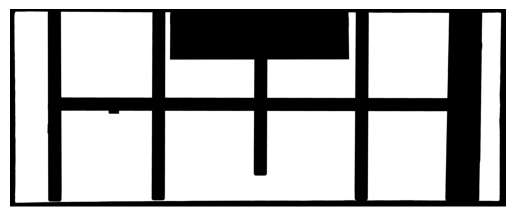

In [ ]:
#get the mask for an image and rotate it back if original image was rotated
f = data[0]["filename"]
mask = get_mask(f)
if f in files_rotated:
    print("Rotate mask")
    mask = cv2.rotate(mask, cv2.ROTATE_180)
rgb_image = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

In [17]:
#compute which rectangles are overlapping with the mask
r = data[1]["false_negatives"]["boxes"]
overlaps = compute_mask_coverage(mask, r, threshold = 0.5)
overlaps

[(0, np.float64(0.6850080438279925), np.True_),
 (1, np.float64(0.811633482747837), np.True_),
 (2, np.float64(0.9158620689655173), np.True_),
 (3, np.float64(0.991509518276879), np.True_),
 (4, np.float64(0.3539041404140414), np.False_),
 (5, np.float64(0.13101045296167246), np.False_),
 (6, np.float64(0.7815157894736842), np.True_),
 (7, np.float64(0.0), np.False_),
 (8, np.float64(0.20460158585727284), np.False_),
 (9, np.float64(0.5289309366130558), np.True_),
 (10, np.float64(0.17086307869875603), np.False_),
 (11, np.float64(0.7524055222423651), np.True_),
 (12, np.float64(0.49638100752750436), np.False_),
 (13, np.float64(0.43743782046376367), np.False_),
 (14, np.float64(0.3932542624166049), np.False_),
 (15, np.float64(0.0), np.False_),
 (16, np.float64(0.3498107852412488), np.False_)]

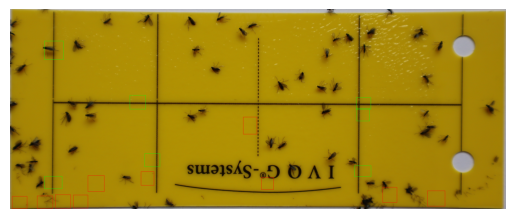

In [19]:
#plot rectangles on image
#green: on mask, red: not (remains false negative)
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val"
img_copy = cv2.imread(os.path.join(image_folder, f))
for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

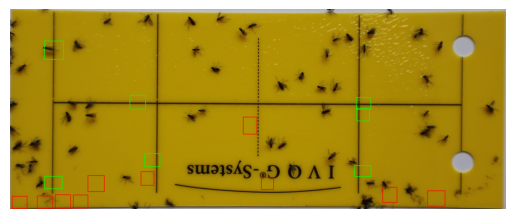

In [21]:
#same for masked image
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val"
img_copy = cv2.imread(os.path.join(image_folder, f))
if f in files_rotated:
    img_copy = cv2.rotate(img_copy, cv2.ROTATE_180)

for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=5)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=5)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
cv2.imwrite("false_negatives_on_mask.jpg",img_copy)

plt.show()

Loading BRAIIM_0319.jpg
using only simple binarization.


using only simple binarization.
31.5
Rotate mask


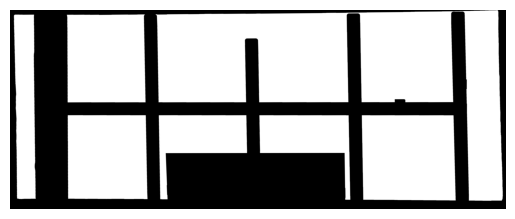

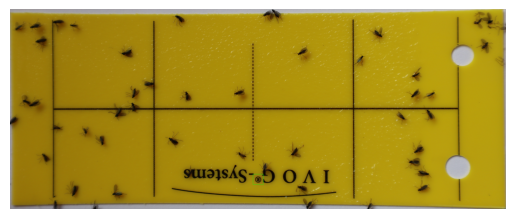

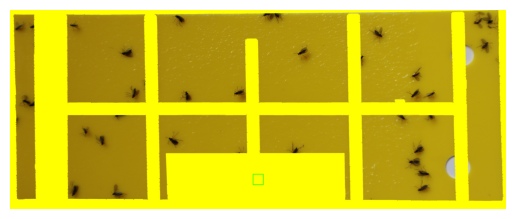

[(0, np.float64(1.0), np.True_)]


In [23]:
#get the mask for an image and rotate it back if original image was rotated
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"
i = 10
f = data[i]["filename"]
mask = get_mask(f)
if f in files_rotated:
    print("Rotate mask")
    mask = cv2.rotate(mask, cv2.ROTATE_180)
rgb_image = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()
#compute which rectangles are overlapping with the mask
r = data[i]["false_positives"]["boxes"]
overlaps = compute_mask_coverage(mask, r, threshold = 1.0)
#plot rectangles on image
#green: on mask, red: not (remains false negative)
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images"
img_copy = cv2.imread(os.path.join(image_folder, f))
for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
#same for masked image
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked"
img_copy = cv2.imread(os.path.join(image_folder, f))
if f in files_rotated:
    img_copy = cv2.rotate(img_copy, cv2.ROTATE_180)

for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=5)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=5)

cv2.imwrite("false_positives_on_mask.jpg",img_copy)
img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()
print(overlaps)

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 40, 'false': 183, 'unchecked': 30},
             'LIRIBO': {'true': 110, 'false': 102, 'unchecked': 25},
             'TRIAVA': {'true': 42, 'false': 38, 'unchecked': 3}})

### Finding Saturation difference in TRIAVA TP/FN

In [ ]:
def mean_hsv_otsu(box, img):
    x1, y1, x2, y2 = map(int, box)
    roi = img[y1:y2, x1:x2]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    v_channel = hsv[:, :, 2]

    # Apply Otsu's threshold on V
    _, mask = cv2.threshold(v_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Convert mask to boolean for indexing
    mask_bool = mask == 255

    s_pixels = hsv[:, :, 1][mask_bool]
    v_pixels = hsv[:, :, 2][mask_bool]

    if s_pixels.size == 0 or v_pixels.size == 0:
        return (np.nan, np.nan)

    mean_s = float(np.mean(s_pixels))
    mean_v = float(np.mean(v_pixels))

    return (mean_s, mean_v)


def mean_hsv_box(box, img):
    x1, y1, x2, y2 = map(int, box)
    roi = img[y1:y2, x1:x2]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    return hsv[:, :, 1].mean(), hsv[:, :, 2].mean()  # (S, V)

In [23]:
f = "TRIAVA_0058.jpg"
f = "TRIAVA_0345.jpg"
for item in data:
    if item["filename"] == f:
        result = item
        break
item

{'filename': 'TRIAVA_0345.jpg',
 'true_positives': {'boxes': [[4831.60498046875,
    1999.07275390625,
    4883.07470703125,
    2038.127685546875],
   [4513.66259765625, 1590.619384765625, 4563.185546875, 1637.352783203125],
   [2110.505126953125, 2157.970703125, 2161.059326171875, 2224.884521484375],
   [3108.36669921875, 552.0505981445312, 3146.880859375, 596.7876586914062],
   [4635.62255859375, 891.2088012695312, 4678.5029296875, 934.4562377929688],
   [2381.71240234375, 944.1298217773438, 2419.9677734375, 997.4615478515625],
   [3940.69775390625, 1183.981201171875, 3998.69189453125, 1227.7491455078125],
   [4784.54052734375, 760.7503662109375, 4818.95263671875, 803.063232421875],
   [5176.8740234375, 550.9352416992188, 5209.5927734375, 585.3551025390625],
   [3307.32958984375, 1245.951416015625, 3355.6513671875, 1274.70751953125],
   [3111.12109375, 1540.982177734375, 3134.302001953125, 1576.0528564453125],
   [4703.896484375, 1365.783203125, 4746.5263671875, 1396.435546875],
   

In [24]:
fn = item["false_negatives"]["boxes"]
tp = item["true_positives"]["boxes"]
fn

[[114.81719207763672, 308.8199462890625, 187.86134338378906, 372.4990234375],
 [1777.3431396484375, 455.1586608886719, 1858.63623046875, 519.8589477539062],
 [1976.55712890625, 2252.44873046875, 2048.66259765625, 2316.1279296875],
 [2121.709716796875, 2229.036865234375, 2182.579833984375, 2302.079833984375],
 [2306.194580078125, 2030.5081787109375, 2365.193115234375, 2085.759521484375],
 [2384.856201171875, 2095.123291015625, 2426.9990234375, 2148.50244140625],
 [2469.1357421875, 2210.30810546875, 2505.65771484375, 2260.87646484375],
 [2467.26123046875, 2266.494384765625, 2515.957275390625, 2310.50732421875],
 [2620.47509765625, 2279.537841796875, 2667.616455078125, 2325.269287109375],
 [2715.441162109375, 2266.417724609375, 2774.287109375, 2315.666748046875],
 [2659.795654296875, 2212.05029296875, 2705.845703125, 2274.093505859375],
 [2703.290771484375, 2228.039306640625, 2741.027099609375, 2268.3359375],
 [2785.80126953125, 2153.843994140625, 2853.371337890625, 2207.06005859375],
 [2

In [25]:
import cv2
import numpy as np

def mean_hsv_box(box, img):
    """Compute mean (H, S, V) inside a bounding box."""
    x1, y1, x2, y2 = map(int, box)
    roi = img[y1:y2, x1:x2]

    if roi.size == 0:
        return (np.nan, np.nan, np.nan)

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    mean_h = float(np.mean(hsv[:, :, 0]))
    mean_s = float(np.mean(hsv[:, :, 1]))
    mean_v = float(np.mean(hsv[:, :, 2]))

    return (mean_h, mean_s, mean_v)


img = cv2.imread(os.path.join(
        #"/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images", f
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val", f
    ))
fn_hsv = [mean_hsv_box(box, img) for box in fn]
tp_hsv = [mean_hsv_box(box, img) for box in tp]
fn_hsv

[(22.79794520547945, 227.09203767123287, 139.37328767123287),
 (23.466435185185187, 220.15547839506172, 147.7993827160494),
 (23.309244791666668, 229.21766493055554, 148.14322916666666),
 (22.798338198966988, 195.59892207500562, 145.37412980013474),
 (22.746070878274267, 199.14607087827426, 143.3106317411402),
 (23.19946091644205, 189.57861635220127, 123.64690026954177),
 (22.788333333333334, 175.39388888888888, 148.40944444444443),
 (22.202651515151516, 211.6846590909091, 131.34469696969697),
 (21.943108233117485, 136.0518038852914, 142.209065679926),
 (22.707713593912143, 184.0985818056036, 144.65859564164649),
 (22.295582047685834, 171.80434782608697, 149.08800841514727),
 (21.73355263157895, 154.94736842105263, 149.09473684210528),
 (22.835511982570807, 198.22031590413943, 147.67347494553377),
 (23.067527308838134, 215.93512082092022, 148.21052631578948),
 (22.965384615384615, 206.6184210526316, 145.49817813765182),
 (23.173021181716834, 218.41159420289856, 150.84682274247493),
 (2

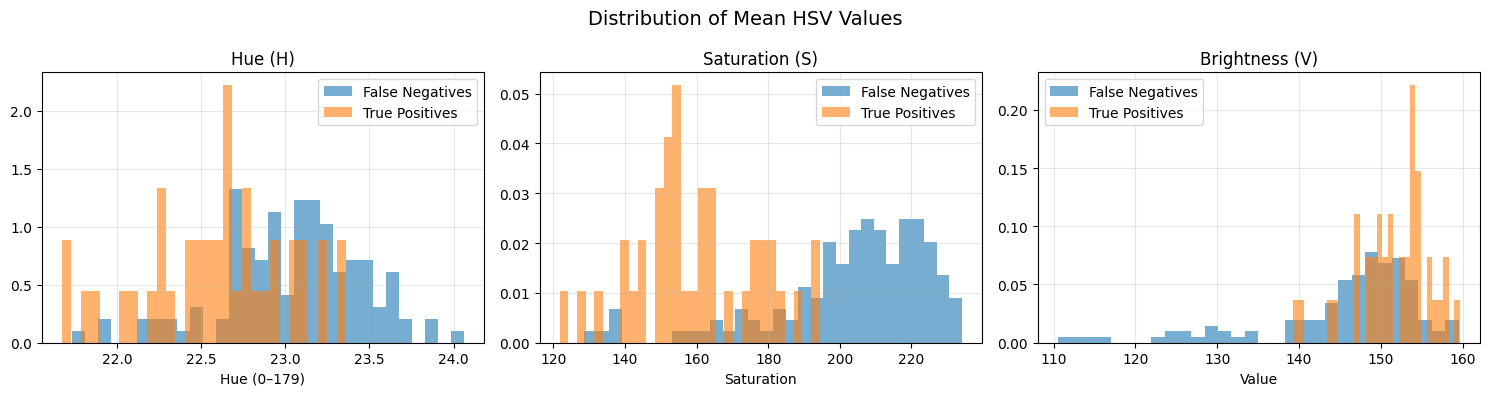

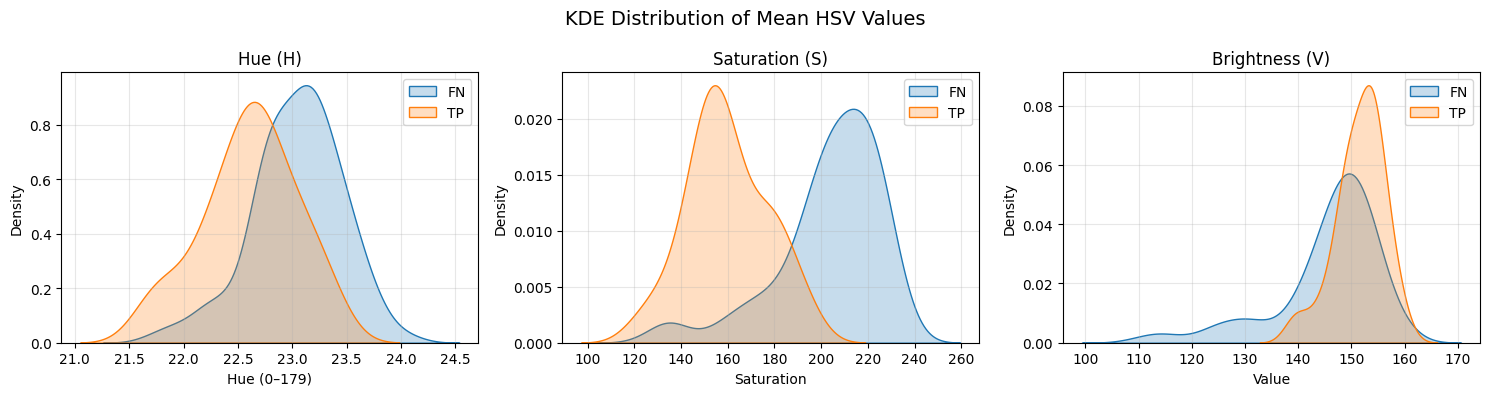

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# fn_hsv and tp_hsv should be lists of (H, S, V) tuples
fn_hsv = np.array(fn_hsv)
tp_hsv = np.array(tp_hsv)

# Remove NaN entries
fn_hsv = fn_hsv[~np.isnan(fn_hsv).any(axis=1)]
tp_hsv = tp_hsv[~np.isnan(tp_hsv).any(axis=1)]

# Separate H, S, V channels
fn_h, fn_s, fn_v = fn_hsv[:, 0], fn_hsv[:, 1], fn_hsv[:, 2]
tp_h, tp_s, tp_v = tp_hsv[:, 0], tp_hsv[:, 1], tp_hsv[:, 2]

# --- HISTOGRAM VERSION ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fn_h, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[0].hist(tp_h, bins=30, alpha=0.6, label="True Positives", density=True)
axes[0].set_title("Hue (H)")
axes[0].set_xlabel("Hue (0–179)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(fn_s, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[1].hist(tp_s, bins=30, alpha=0.6, label="True Positives", density=True)
axes[1].set_title("Saturation (S)")
axes[1].set_xlabel("Saturation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(fn_v, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[2].hist(tp_v, bins=30, alpha=0.6, label="True Positives", density=True)
axes[2].set_title("Brightness (V)")
axes[2].set_xlabel("Value")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Distribution of Mean HSV Values", fontsize=14)
plt.tight_layout()
plt.show()

# --- OPTIONAL: KDE VERSION (SMOOTH CURVES) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(fn_h, label="FN", fill=True, ax=axes[0])
sns.kdeplot(tp_h, label="TP", fill=True, ax=axes[0])
axes[0].set_title("Hue (H)")
axes[0].set_xlabel("Hue (0–179)")

sns.kdeplot(fn_s, label="FN", fill=True, ax=axes[1])
sns.kdeplot(tp_s, label="TP", fill=True, ax=axes[1])
axes[1].set_title("Saturation (S)")
axes[1].set_xlabel("Saturation")

sns.kdeplot(fn_v, label="FN", fill=True, ax=axes[2])
sns.kdeplot(tp_v, label="TP", fill=True, ax=axes[2])
axes[2].set_title("Brightness (V)")
axes[2].set_xlabel("Value")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("KDE Distribution of Mean HSV Values", fontsize=14)
plt.tight_layout()
plt.show()


In [29]:
tp_s_means = []
tp_v_means = []
tp_h_means = []
fn_s_means = []
fn_v_means = []
fn_h_means = []

for i in range(len(data)):
    f = data[i]["filename"]
    if not f.startswith("TRIAVA"):
        continue

    fn = data[i]["false_negatives"]["boxes"]
    tp = data[i]["true_positives"]["boxes"]


    img = cv2.imread(os.path.join(
        #"/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images", f
        "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/split/images/val", f
    ))

    #fn_sv = [mean_hsv_box(box, img) for box in filtered_fn]
    fn_hsv = [mean_hsv_box(box, img) for box in fn]
    tp_hsv = [mean_hsv_box(box, img) for box in tp]


    if fn_hsv:  # only if not empty
        fn_h, fn_s, fn_v = zip(*fn_hsv)
        fn_h_means.extend(fn_h)
        fn_s_means.extend(fn_s)
        fn_v_means.extend(fn_v)

    if tp_hsv:
        tp_h,tp_s, tp_v = zip(*tp_hsv)
        tp_h_means.extend(tp_h)
        tp_s_means.extend(tp_s)
        tp_v_means.extend(tp_v)



Mean Saturation (FN): 196.6980616566658
Mean Value (FN): 152.02427475038095
Mean Saturation (TP): 156.03846389861292
Mean Value (TP): 158.19149636287844


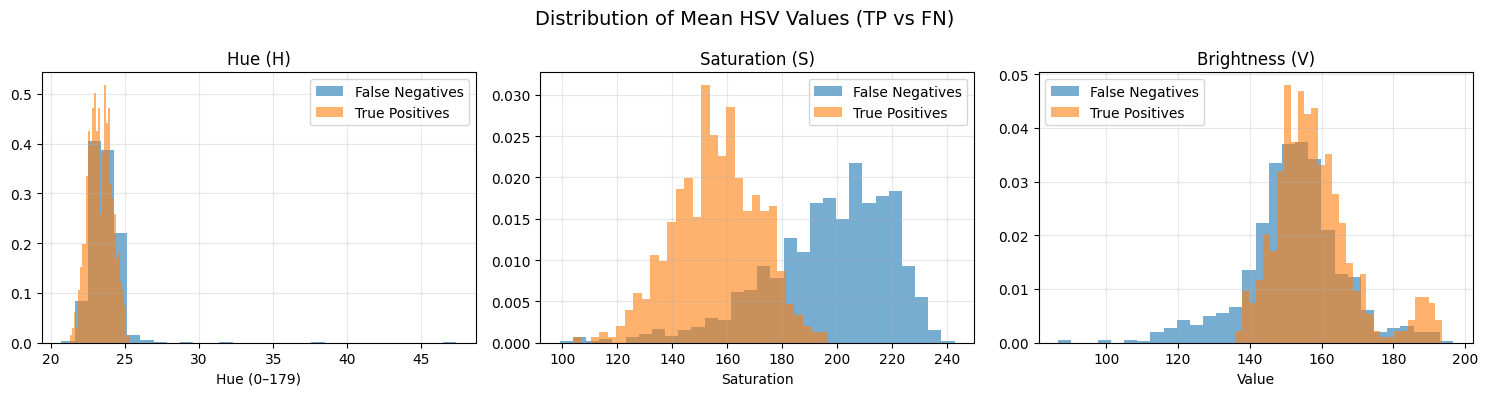

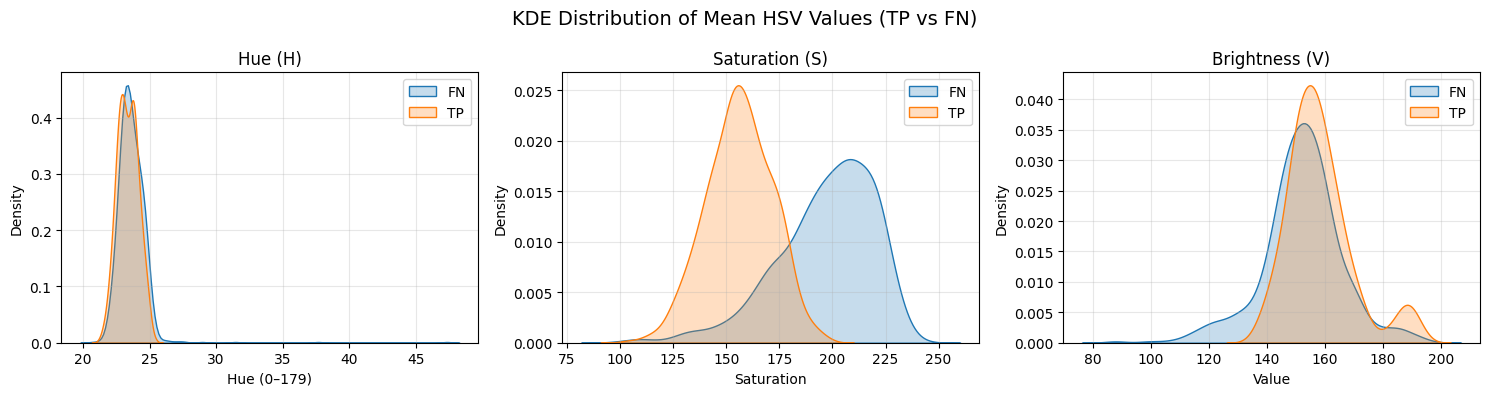

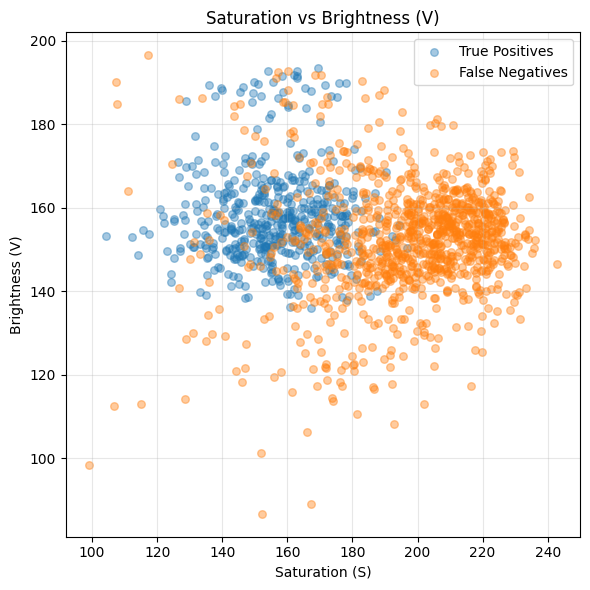

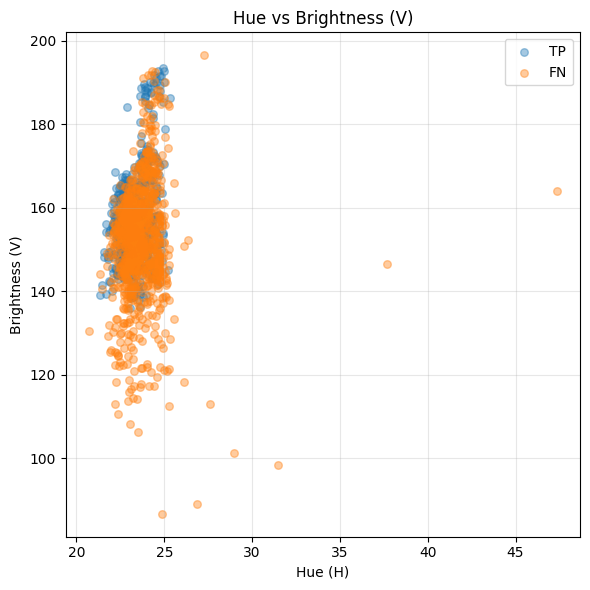

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to numpy arrays and remove NaNs (if any)
tp_h = np.array(tp_h_means)
tp_s = np.array(tp_s_means)
tp_v = np.array(tp_v_means)
fn_h = np.array(fn_h_means)
fn_s = np.array(fn_s_means)
fn_v = np.array(fn_v_means)

# Remove NaN entries
tp_mask = ~np.isnan(tp_h) & ~np.isnan(tp_s) & ~np.isnan(tp_v)
fn_mask = ~np.isnan(fn_h) & ~np.isnan(fn_s) & ~np.isnan(fn_v)

tp_h, tp_s, tp_v = tp_h[tp_mask], tp_s[tp_mask], tp_v[tp_mask]
fn_h, fn_s, fn_v = fn_h[fn_mask], fn_s[fn_mask], fn_v[fn_mask]

# --- HISTOGRAM COMPARISON FOR EACH HSV CHANNEL ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(fn_h, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[0].hist(tp_h, bins=30, alpha=0.6, label="True Positives", density=True)
axes[0].set_title("Hue (H)")
axes[0].set_xlabel("Hue (0–179)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(fn_s, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[1].hist(tp_s, bins=30, alpha=0.6, label="True Positives", density=True)
axes[1].set_title("Saturation (S)")
axes[1].set_xlabel("Saturation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(fn_v, bins=30, alpha=0.6, label="False Negatives", density=True)
axes[2].hist(tp_v, bins=30, alpha=0.6, label="True Positives", density=True)
axes[2].set_title("Brightness (V)")
axes[2].set_xlabel("Value")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Distribution of Mean HSV Values (TP vs FN)", fontsize=14)
plt.tight_layout()
plt.show()

# --- OPTIONAL: SMOOTH KDE CURVES (Nicer Overlay) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(fn_h, label="FN", fill=True, ax=axes[0])
sns.kdeplot(tp_h, label="TP", fill=True, ax=axes[0])
axes[0].set_title("Hue (H)")
axes[0].set_xlabel("Hue (0–179)")

sns.kdeplot(fn_s, label="FN", fill=True, ax=axes[1])
sns.kdeplot(tp_s, label="TP", fill=True, ax=axes[1])
axes[1].set_title("Saturation (S)")
axes[1].set_xlabel("Saturation")

sns.kdeplot(fn_v, label="FN", fill=True, ax=axes[2])
sns.kdeplot(tp_v, label="TP", fill=True, ax=axes[2])
axes[2].set_title("Brightness (V)")
axes[2].set_xlabel("Value")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("KDE Distribution of Mean HSV Values (TP vs FN)", fontsize=14)
plt.tight_layout()
plt.show()

# --- SCATTER PLOTS TO SEE RELATIONSHIPS ---
plt.figure(figsize=(6,6))
plt.scatter(tp_s, tp_v, alpha=0.4, label='True Positives', s=30)
plt.scatter(fn_s, fn_v, alpha=0.4, label='False Negatives', s=30)
plt.xlabel("Saturation (S)")
plt.ylabel("Brightness (V)")
plt.title("Saturation vs Brightness (V)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Hue vs Value or Hue vs Saturation
plt.figure(figsize=(6,6))
plt.scatter(tp_h, tp_v, alpha=0.4, label='TP', s=30)
plt.scatter(fn_h, fn_v, alpha=0.4, label='FN', s=30)
plt.xlabel("Hue (H)")
plt.ylabel("Brightness (V)")
plt.title("Hue vs Brightness (V)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [33]:
print("Mean Saturation (FN):", np.mean(fn_s_means))
print("Mean Value (FN):", np.mean(fn_v_means))
print("Mean Hue (FN):", np.mean(fn_h_means))
print("Mean Saturation (TP):", np.mean(tp_s_means))
print("Mean Value (TP):", np.mean(tp_v_means))
print("Mean Hue (TP):", np.mean(tp_h_means))

Mean Saturation (FN): 196.6980616566658
Mean Value (FN): 152.02427475038095
Mean Hue (FN): 23.633412372847424
Mean Saturation (TP): 156.03846389861292
Mean Value (TP): 158.19149636287844
Mean Hue (TP): 23.343872326914045


In [34]:
def summarize_channel(name, tp_vals, fn_vals):
    tp_vals, fn_vals = np.array(tp_vals), np.array(fn_vals)
    tp_mean, fn_mean = np.nanmean(tp_vals), np.nanmean(fn_vals)
    tp_std, fn_std = np.nanstd(tp_vals), np.nanstd(fn_vals)
    print(f"{name}:")
    print(f"  TP mean = {tp_mean:.2f}, std = {tp_std:.2f}")
    print(f"  FN mean = {fn_mean:.2f}, std = {fn_std:.2f}")
    print(f"  Δmean (FN–TP) = {fn_mean - tp_mean:.2f}")
    print(f"  Δstd  (FN–TP) = {fn_std - tp_std:.2f}")
    print()

summarize_channel("Hue", tp_h_means, fn_h_means)
summarize_channel("Saturation", tp_s_means, fn_s_means)
summarize_channel("Value", tp_v_means, fn_v_means)

Hue:
  TP mean = 23.34, std = 0.78
  FN mean = 23.63, std = 1.23
  Δmean (FN–TP) = 0.29
  Δstd  (FN–TP) = 0.46

Saturation:
  TP mean = 156.04, std = 15.43
  FN mean = 196.70, std = 23.05
  Δmean (FN–TP) = 40.66
  Δstd  (FN–TP) = 7.61

Value:
  TP mean = 158.19, std = 11.41
  FN mean = 152.02, std = 13.85
  Δmean (FN–TP) = -6.17
  Δstd  (FN–TP) = 2.44

